In [1]:
# ============================================================
# Cell 1. Import libraries
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# ============================================================
# Cell 2. Input RMSE results
# ============================================================

data = {
    "Method": [
        "GigaPose",
        "FoundationPose",
        "Domain expert (manual)",
        "HccePose"
    ],
    "Edge_RMSE_px": [
        4.9403,
        5.0862,
        5.7127,
        6.5569
    ]
}

df = pd.DataFrame(data)
df

,Method,Edge_RMSE_px
0,GigaPose,4.9403
1,FoundationPose,5.0862
2,Domain expert (manual),5.7127
3,HccePose,6.5569


In [3]:
# ============================================================
# Cell 3. Set representative GT edge length
# ============================================================
# IMPORTANT:
# Replace this value with the mean GT edge length in pixels
# computed from your annotated SEM images.
#
# Example:
# If the average ground-truth edge length is 80 px,
# then edge relative RMSE = RMSE / 80.

mean_gt_edge_px = 80.0  # <-- change this value based on your dataset

df["Edge_Error_Rate_%"] = df["Edge_RMSE_px"] / mean_gt_edge_px * 100

# Since D ∝ l^2 and P ∝ D under constant solubility,
# the propagated error rate is calculated by the quadratic relation.
relative_edge_error = df["Edge_RMSE_px"] / mean_gt_edge_px

df["Diffusivity_Error_Rate_%"] = ((1 + relative_edge_error) ** 2 - 1) * 100
df["Permeability_Error_Rate_%"] = df["Diffusivity_Error_Rate_%"]

df

,Method,Edge_RMSE_px,Edge_Error_Rate_%,Diffusivity_Error_Rate_%,Permeability_Error_Rate_%
0,GigaPose,4.9403,6.175375,12.732103,12.732103
1,FoundationPose,5.0862,6.357750,13.119710,13.119710
2,Domain expert (manual),5.7127,7.140875,14.791671,14.791671
3,HccePose,6.5569,8.196125,17.064015,17.064015


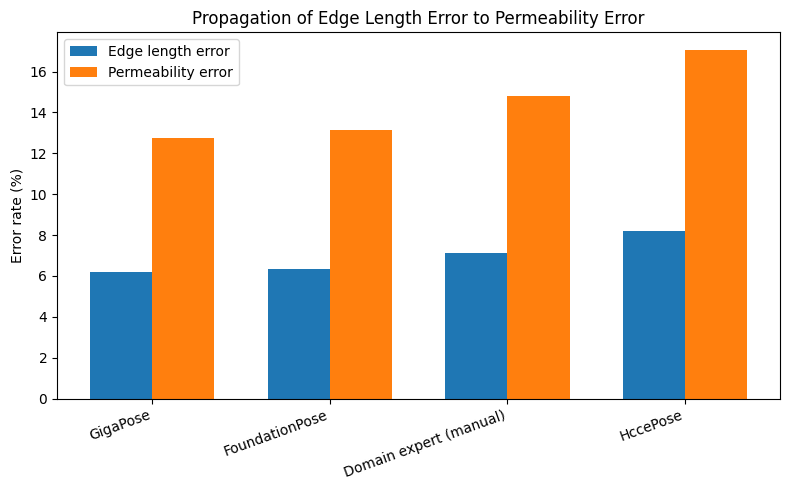

In [4]:
# ============================================================
# Cell 4. Plot edge error vs diffusivity/permeability error
# ============================================================

plt.figure(figsize=(8, 5))

x = np.arange(len(df))
bar_width = 0.35

plt.bar(
    x - bar_width / 2,
    df["Edge_Error_Rate_%"],
    width=bar_width,
    label="Edge length error"
)

plt.bar(
    x + bar_width / 2,
    df["Permeability_Error_Rate_%"],
    width=bar_width,
    label="Permeability error"
)

plt.xticks(x, df["Method"], rotation=20, ha="right")
plt.ylabel("Error rate (%)")
plt.title("Propagation of Edge Length Error to Permeability Error")
plt.legend()
plt.tight_layout()
plt.show()

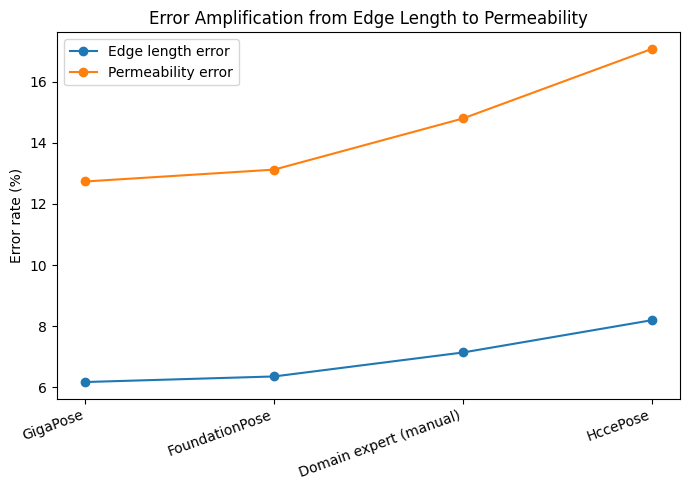

In [5]:
# ============================================================
# Cell 5. Line plot version
# ============================================================

plt.figure(figsize=(7, 5))

plt.plot(
    df["Method"],
    df["Edge_Error_Rate_%"],
    marker="o",
    label="Edge length error"
)

plt.plot(
    df["Method"],
    df["Permeability_Error_Rate_%"],
    marker="o",
    label="Permeability error"
)

plt.xticks(rotation=20, ha="right")
plt.ylabel("Error rate (%)")
plt.title("Error Amplification from Edge Length to Permeability")
plt.legend()
plt.tight_layout()
plt.show()

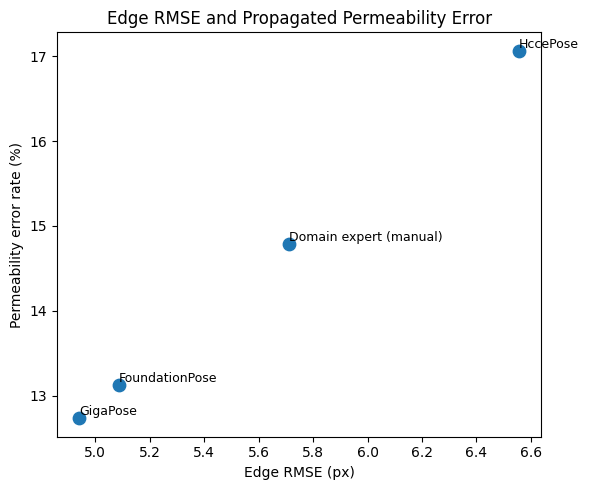

In [6]:
# ============================================================
# Cell 6. Scatter plot: edge RMSE vs permeability error
# ============================================================

plt.figure(figsize=(6, 5))

plt.scatter(
    df["Edge_RMSE_px"],
    df["Permeability_Error_Rate_%"],
    s=80
)

for _, row in df.iterrows():
    plt.text(
        row["Edge_RMSE_px"],
        row["Permeability_Error_Rate_%"],
        row["Method"],
        fontsize=9,
        ha="left",
        va="bottom"
    )

plt.xlabel("Edge RMSE (px)")
plt.ylabel("Permeability error rate (%)")
plt.title("Edge RMSE and Propagated Permeability Error")
plt.tight_layout()
plt.show()

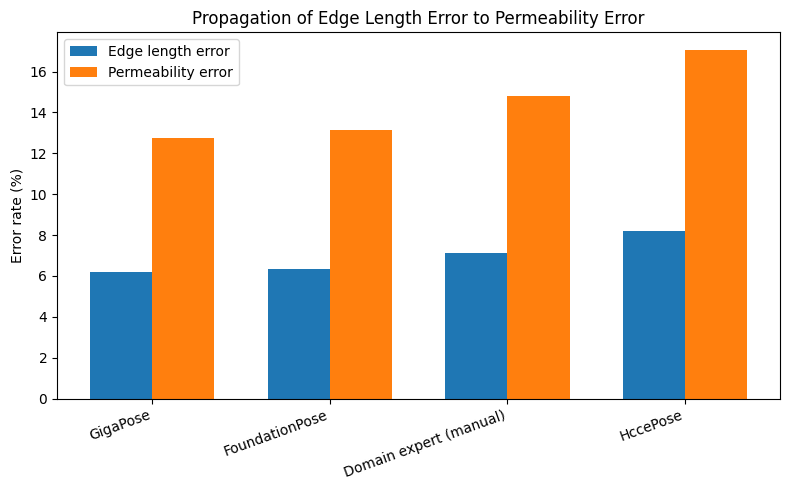

In [7]:
# ============================================================
# Cell 7. Save figure for paper
# ============================================================

plt.figure(figsize=(8, 5))

x = np.arange(len(df))
bar_width = 0.35

plt.bar(
    x - bar_width / 2,
    df["Edge_Error_Rate_%"],
    width=bar_width,
    label="Edge length error"
)

plt.bar(
    x + bar_width / 2,
    df["Permeability_Error_Rate_%"],
    width=bar_width,
    label="Permeability error"
)

plt.xticks(x, df["Method"], rotation=20, ha="right")
plt.ylabel("Error rate (%)")
plt.title("Propagation of Edge Length Error to Permeability Error")
plt.legend()
plt.tight_layout()

plt.savefig("edge_to_permeability_error.pdf", bbox_inches="tight")
plt.savefig("edge_to_permeability_error.png", dpi=300, bbox_inches="tight")

plt.show()